In [2]:
%cd ~/ClimCorrector/models/swintransformer_v2

/n/home03/qiyusong/ClimCorrector/models/swintransformer_v2


/n/holylfs04/LABS/kuang_lab/Lab/qiyusong/mamba_envs/climcorr/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/n/holylfs04/LABS/kuang_lab/Lab/qiyusong/mamba_envs/climcorr/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
import torch
import numpy as np
import modulus
from utils.data_utils import *

from tqdm import tqdm
from swintransformer_modulus import SwinTransformerV2CrModulus
import swintransformer_modulus as swintransformer_modulus

/n/holylfs04/LABS/kuang_lab/Lab/qiyusong/mamba_envs/climcorr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/n/holylfs04/LABS/kuang_lab/Lab/qiyusong/mamba_envs/climcorr/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


# load model weight

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model_inf = modulus.Module.from_checkpoint("/glade/campaign/univ/uhar0026/zeyuanhu/tutorial/saved_models/swinv3_halfforce2/ckpt/ckpt_epoch_1_metric_0.1775.mdlus").to(device)
model_inf = modulus.Module.from_checkpoint("/n/home03/qiyusong/saved_models/swinv3_dim1024_depth8_trial/ckpt/ckpt_epoch_39_metric_0.1860.mdlus").to(device)


/n/holylfs04/LABS/kuang_lab/Lab/qiyusong/mamba_envs/climcorr/lib/python3.10/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [5]:
# Function to count total parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total number of parameters:", count_parameters(model_inf))

Total number of parameters: 67487872


In [6]:
# parent_path = '/glade/campaign/univ/uhar0026/zeyuanhu/v3_iter2_4year_sub3_processed/v2_val/'
parent_path = '/n/holylfs04/LABS/kuang_lab/Lab/qiyusong/ClimCorr_data/v3_halfforce_4year_sub3_processed/'
input_path = f'{parent_path}/val_input.h5'
target_path = f'{parent_path}/val_target_sum.h5'
input_file = h5py.File(input_path, 'r')
target_file = h5py.File(target_path, 'r')
x = input_file['data'][:]
y = target_file['data'][:]
x = torch.from_numpy(x).to(torch.float32)
y = torch.from_numpy(y).to(torch.float32)
x = x.permute(0, 3, 1, 2)
y = y.permute(0, 3, 1, 2)

In [7]:
x.shape

torch.Size([1948, 142, 96, 144])

In [6]:
device

device(type='cuda')

In [7]:
x.shape

torch.Size([1948, 142, 96, 144])

In [8]:
# do the inference here
batch = 16
pred = np.zeros(y.shape)
ibatch = x.shape[0]//batch+1 if x.shape[0]%batch!=0 else x.shape[0]//batch
with torch.no_grad():  # Disable gradient computation
    for i in tqdm(range(ibatch), desc="Processing Batches"):
        pred[i * batch: (i + 1) * batch, :] = model_inf(
            x[i * batch: (i + 1) * batch, :].to(device)
        ).to("cpu").numpy()
print(pred.shape)

Processing Batches:   0%|          | 0/122 [00:00<?, ?it/s]

Processing Batches: 100%|██████████| 122/122 [04:41<00:00,  2.31s/it]

(1948, 104, 96, 144)


In [9]:
# this block calculate the r2 over time dimension (r2_3d), and then do zonal average r2_zonal

y_numpy = y.numpy()
ss_orig_time = np.sum((y_numpy - pred) ** 2, axis=0)

# Calculate the denominator (total sum of squares)
ss_tot_time = np.sum((y_numpy - np.mean(y_numpy, axis=0)) ** 2, axis=0)

# Calculate R^2 for each feature
r2_3d = 1 - (ss_orig_time / ss_tot_time)

r2_zonal = r2_3d.mean(axis=2).transpose()

In [10]:
# read lat and lev information

lat = np.array([-90.      , -88.105263, -86.210526, -84.315789, -82.421053, -80.526316,
       -78.631579, -76.736842, -74.842105, -72.947368, -71.052632, -69.157895,
       -67.263158, -65.368421, -63.473684, -61.578947, -59.684211, -57.789474,
       -55.894737, -54.      , -52.105263, -50.210526, -48.315789, -46.421053,
       -44.526316, -42.631579, -40.736842, -38.842105, -36.947368, -35.052632,
       -33.157895, -31.263158, -29.368421, -27.473684, -25.578947, -23.684211,
       -21.789474, -19.894737, -18.      , -16.105263, -14.210526, -12.315789,
       -10.421053,  -8.526316,  -6.631579,  -4.736842,  -2.842105,  -0.947368,
         0.947368,   2.842105,   4.736842,   6.631579,   8.526316,  10.421053,
        12.315789,  14.210526,  16.105263,  18.      ,  19.894737,  21.789474,
        23.684211,  25.578947,  27.473684,  29.368421,  31.263158,  33.157895,
        35.052632,  36.947368,  38.842105,  40.736842,  42.631579,  44.526316,
        46.421053,  48.315789,  50.210526,  52.105263,  54.      ,  55.894737,
        57.789474,  59.684211,  61.578947,  63.473684,  65.368421,  67.263158,
        69.157895,  71.052632,  72.947368,  74.842105,  76.736842,  78.631579,
        80.526316,  82.421053,  84.315789,  86.210526,  88.105263,  90.      ])

lev = np.array([3.54463800000001, 7.38881350000001, 13.967214, 23.944625, 
    37.2302900000001, 53.1146050000002, 70.0591500000003, 85.4391150000003, 
    100.514695, 118.250335, 139.115395, 163.66207, 192.539935, 226.513265, 
    266.481155, 313.501265000001, 368.817980000002, 433.895225000001, 
    510.455255000002, 600.524200000003, 696.796290000003, 787.702060000003, 
    867.160760000001, 929.648875000002, 970.554830000001, 992.5561])

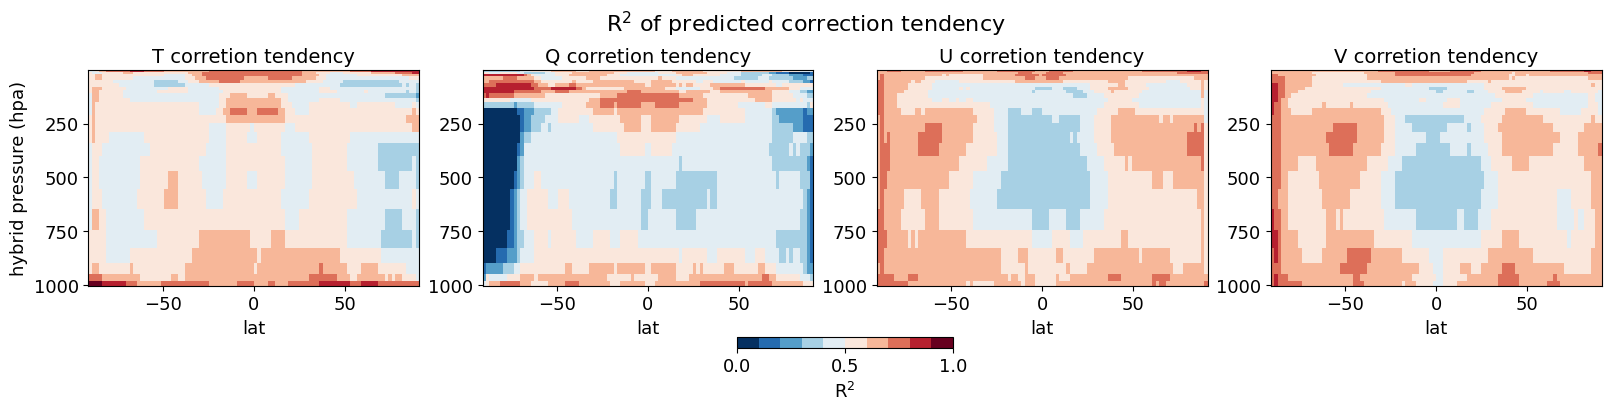

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual data)
# Set up a 1x4 subplot (4 panels in a row)
fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)

# Panel titles
titles = ['T corretion tendency', 'Q corretion tendency', 'U corretion tendency', 'V corretion tendency']

# Define colormap with 10 discrete colors
cmap = plt.get_cmap('RdBu_r', 10)

# Font size settings
title_fontsize = 14
label_fontsize = 13
tick_fontsize = 13
colorbar_fontsize = 13
suptitle_fontsize = 16

# Loop through each panel and plot the corresponding slice
for i, ax in enumerate(axes):
    start = i * 26
    end = start + 26
    mesh = ax.pcolormesh(
        lat, lev, r2_zonal[:, start:end].transpose(), cmap=cmap, shading='auto', vmin=0, vmax=1
    )
    ax.set_title(titles[i], fontsize=title_fontsize)  # Set title for each panel
    ax.set_xlabel('lat', fontsize=label_fontsize)
    if i == 0:
        ax.set_ylabel('hybrid pressure (hpa)', fontsize=label_fontsize)
    else:
        ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=tick_fontsize)  # Adjust tick font size
    ax.invert_yaxis()  # Reverse y-axis

# Add a single colorbar for all panels
cbar = fig.colorbar(mesh, ax=axes, orientation='horizontal', fraction=0.05, pad=0.0)
cbar.set_label('R$^2$', fontsize=colorbar_fontsize)
cbar.ax.tick_params(labelsize=tick_fontsize)  # Adjust colorbar tick font size

# Set the main title font size
fig.suptitle('R$^2$ of predicted correction tendency', fontsize=suptitle_fontsize)

# Save the figure
# plt.savefig('proposal_bias_correction.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

Below is to use Will's color scheme (I tried my best to make it look like the same used in his paper)

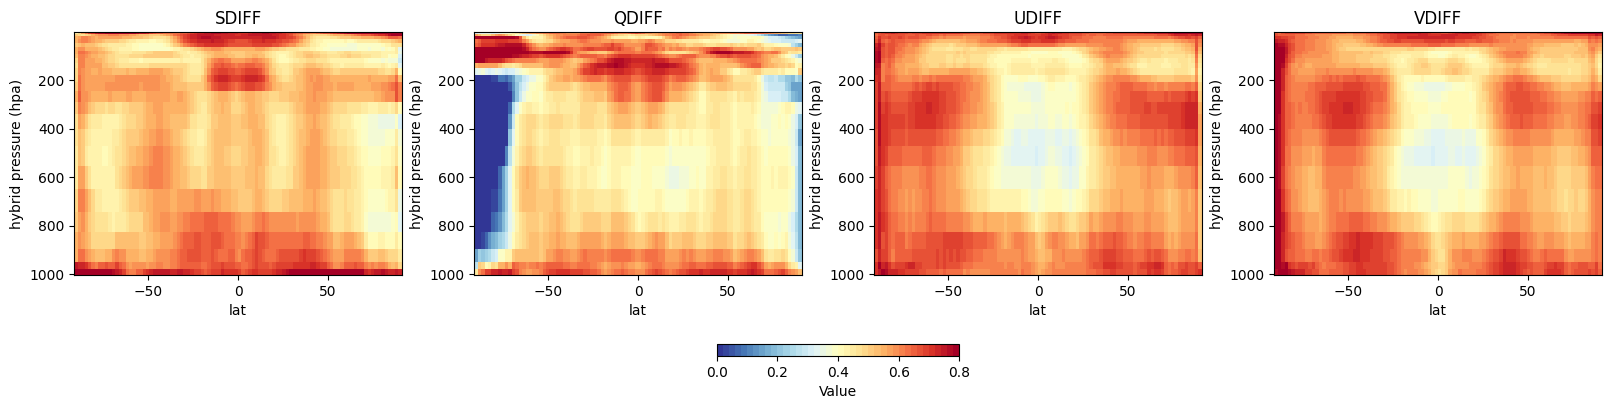

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual data)
# Set up a 1x4 subplot (4 panels in a row)
fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)

# Panel titles
titles = ['SDIFF', 'QDIFF', 'UDIFF', 'VDIFF']

# Define colormap with 10 discrete colors
cmap = plt.get_cmap('RdYlBu_r', 40)

# Loop through each panel and plot the corresponding slice
for i, ax in enumerate(axes):
    start = i * 26
    end = start + 26
    mesh = ax.pcolormesh(
        lat, lev, r2_zonal[:, start:end].transpose(), cmap=cmap, shading='auto', vmin=0, vmax=0.8
    )
    ax.set_title(titles[i])  # Set title for each panel
    ax.set_xlabel('lat')
    ax.set_ylabel('hybrid pressure (hpa)')
    ax.invert_yaxis()  # Reverse y-axis
    
#     # Set x-axis ticks and labels using the corresponding lat indices
#     x_ticks = np.linspace(0, len(lat[start:end]) - 1, 5, dtype=int)  # Select 5 tick positions
#     ax.set_xticks(x_ticks)
#     ax.set_xticklabels([f"{lat[start + tick]:.1f}" for tick in x_ticks])
    
#     # Set y-axis ticks and labels using pressure levels
#     y_ticks = np.linspace(0, len(lev) - 1, 5, dtype=int)  # Select 5 tick positions
#     ax.set_yticks(y_ticks)
#     ax.set_yticklabels([f"{lev[tick]:.0f}" for tick in y_ticks])

# Add a single colorbar for all panels
fig.colorbar(mesh, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1, label='Value')

plt.show()
